# Treatment and the four modes of therapeutic escape

A tumour that relapses under therapy did so for one of a small number of reasons, and which one
matters clinically: only some are preventable by changing the course. [Kane et
al. (2026)](https://doi.org/10.64898/2025.12.29.696883) organise this into **four modes of clonal
expansion under treatment**, and this notebook reproduces all four in `iscc`.

|   | tumour responds? | where the relapsing lineage came from |
|---|---|---|
| **I**  | no  | resistance is common and cost-free — the deposit already carries it |
| **II** | no  | resistance is advantageous and swept to fixation *before* therapy |
| **III**| yes | a rare pre-existing clone, present at the first dose, expands under it |
| **IV** | yes | no resistant cell existed at the first dose — resistance arose **on drug** |

I and II are *primary* resistance: the tumour never responds. III and IV are *acquired*: it regresses
and then relapses, and they differ **only** in whether the relapsing lineage predates treatment. That
is the distinction bulk sequencing at relapse cannot make — the relapsed tumour looks resistant either
way — and it is the one `iscc` knows by construction, because it records which cell first acquired
resistance.

**Only the genetics differ between the panels.** Every mode below is dosed with the same kill model
(`kill_mode="proliferation"`, `kill_rate=1.0`), the same 120-generation course and the same
90-generation drug-free tail. What changes is how frequent resistance is in the founding population
and what it costs.

This notebook **loads pre-computed runs** — each panel grows a tumour to ~85,000 cells and takes
several minutes. Regenerate them with:

```
python validation/validate_escape_modes.py
```

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt

CACHE = os.path.join("..", "validation", ".cache_escape_modes")
MODES = [
    ("I",   "resistance common and free",        "no response"),
    ("II",  "resistance advantageous, sweeps",   "no response"),
    ("III", "rare pre-existing clone",           "responds, relapses from that clone"),
    ("IV",  "de novo under therapy",             "responds, relapses from a lineage born on drug"),
]

if not os.path.isdir(CACHE):
    raise SystemExit(f"no cached runs at {CACHE}\n"
                     f"  generate them first:  python validation/validate_escape_modes.py")

runs = {}
for key, _, _ in MODES:
    z = np.load(os.path.join(CACHE, f"{key}.npz"), allow_pickle=True)
    runs[key] = {k: z[k] for k in z.files}

print(f"{'mode':<5}{'cells at 1st dose':>18}{'resistant':>11}{'response':>10}"
      f"{'relapse':>10}{'% resistant':>13}")
for key, _, _ in MODES:
    r = runs[key]
    s, res = r["sens"].astype(float), r["res"].astype(float)
    c0, c1 = int(r["c0"]), int(r["c1"])
    burden = (s + res)[c0:c1 + 1]
    depth = burden[0] / max(burden.min(), 1.0)      # burden at the first dose / nadir
    tot = max(s[-1] + res[-1], 1)
    print(f"{key:<5}{int(s[c0] + res[c0]):>18,}{int(res[c0]):>11,}{depth:>9.1f}x"
          f"{int(tot):>10,}{100 * res[-1] / tot:>12.2f}%")

mode  cells at 1st dose  resistant  response   relapse  % resistant
I                 2,297      2,297      1.0x    87,591      100.00%
II                2,660      2,594      1.0x    86,364      100.00%
III               2,250         33     11.7x    87,174       99.68%
IV                3,518          0     39.5x    86,117      100.00%


## The four modes

Each panel is the metastatic deposit through treatment: **blue** sensitive cells, **red** resistant,
the shaded band the dosing course, and time measured from the first dose.

Read the left edge of the band first — that is what separates primary from acquired resistance. In
I and II the deposit is already red when dosing starts. In III a thin red sliver is present. In IV
there is none at all, and the red appears *inside* the band.

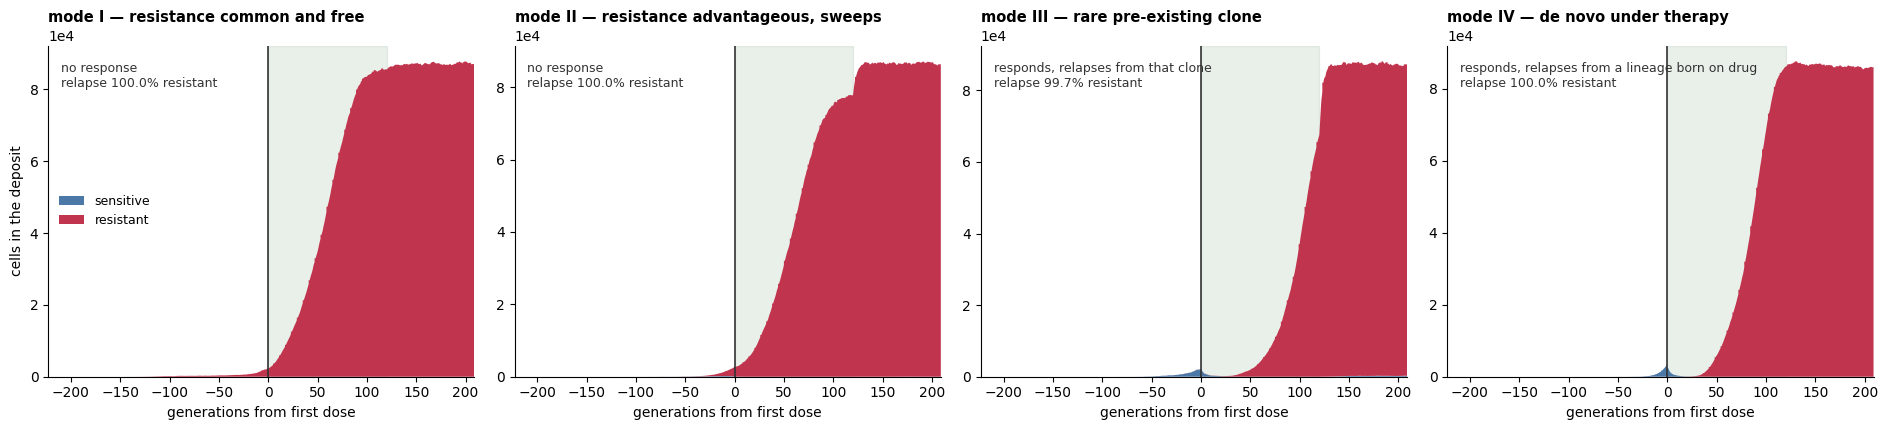

In [2]:
SENS, RES, BAND = "#4c78a8", "#c1344e", "#2f6d3a"
fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))

for ax, (key, genetics, verdict) in zip(axes, MODES):
    r = runs[key]
    s, res = r["sens"].astype(float), r["res"].astype(float)
    c0, c1 = int(r["c0"]), int(r["c1"])
    g = r["trace_gen"].astype(float)
    x = g - g[c0]                                  # generations relative to the first dose
    ax.axvspan(x[c0], x[c1], color=BAND, alpha=0.10, zorder=0)
    ax.stackplot(x, s, res, colors=[SENS, RES], lw=0, labels=["sensitive", "resistant"])
    ax.axvline(0, color="0.2", lw=1.2)
    ax.set_xlim(x[max(c0 - 260, 0)], x[-1]); ax.set_ylim(0, None)
    ax.set_title(f"mode {key} — {genetics}", loc="left", fontsize=10.5, fontweight="bold")
    tot = max(s[-1] + res[-1], 1)
    ax.text(0.03, 0.95, f"{verdict}\nrelapse {100 * res[-1] / tot:.1f}% resistant",
            transform=ax.transAxes, va="top", fontsize=9, color="0.2")
    ax.set_xlabel("generations from first dose")
    ax.spines[["top", "right"]].set_visible(False)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[0].set_ylabel("cells in the deposit")
axes[0].legend(loc="center left", fontsize=9, frameon=False)
fig.tight_layout()

## What separates III from IV

Both respond and both relapse, so the curves alone will not tell them apart. `iscc` records the
generation at which the relapsing lineage first acquired resistance, so the question has an answer
here that no sequencing study could give.

The bar below is that origin, measured relative to the first dose: negative means the lineage existed
before treatment (mode III), positive means it arose while the tumour was on drug (mode IV).

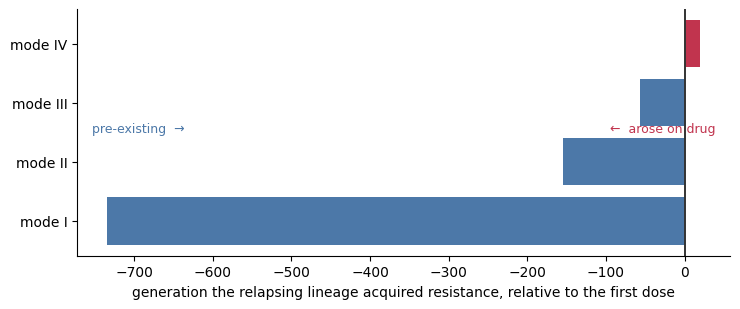

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
labels, origins, cols = [], [], []
for key, _, _ in MODES:
    r = runs[key]
    orow, c0 = int(r["origin_row"]), int(r["c0"])
    g = r["trace_gen"].astype(float)
    origins.append((g[orow] - g[c0]) if orow >= 0 else np.nan)
    labels.append(f"mode {key}")
    cols.append(RES if orow >= c0 else SENS)

ax.barh(labels, origins, color=cols)
ax.axvline(0, color="0.2", lw=1.4)
ax.set_xlabel("generation the relapsing lineage acquired resistance, relative to the first dose")
ax.text(0.01, 0.5, "  pre-existing  →", transform=ax.transAxes, ha="left", fontsize=9, color=SENS)
ax.text(0.99, 0.5, "←  arose on drug  ", transform=ax.transAxes, ha="right", fontsize=9, color=RES)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## Two things worth knowing before reusing this

**Mode IV is stochastic by construction.** It needs a metastatic deposit founded *without* resistance
**and** a de novo lineage that establishes rather than drifting out. The metastatic bottleneck makes
standing resistance in the deposit bimodal rather than smoothly Poisson — either a founder carried it
or none did — so roughly one seed in six yields the mode. The panel above is a selected seed, and any
figure of this kind should say so.

**Mode IV alone is dosed with a mutagenic drug, and that asymmetry is forced.** Since III and IV differ
only in where the relapsing lineage came from, a drug mutagenic enough to manufacture IV's de novo
clone also manufactures one in III, where it outcompetes the pre-existing clone that defines the mode.
Measured: under the same mutagen, mode III falls below its own response threshold and relapses from a
de novo lineage. **No single drug produces all four modes** — that is a property of the definitions,
not a tuning failure.

See `validation/validate_escape_modes.py` for the acceptance criteria each panel is checked against,
and the manuscript section "reproduces the four modes of therapeutic escape".